---
## 🎁 가산점

### A. 데이터의 다양성
- NTP ICE 내 다양한 데이터셋 모두 활용 가능. (https://ice.ntp.niehs.nih.gov/DATASETDESCRIPTION)
### B. Feature(descriptor)의 다양성
- rdkit, VEGA, 등
### 💬 추가 설명 (자유 기술)
- NTP ICE에서 Acute Oral Toxicity + Skin Sensitization 2개 데이터셋 통합 활용
- RDKit 2D descriptor(217개), ECFP4(2048개), MACCS Keys(167개), RDKit Fingerprint(2048개) 총 4종 descriptor 계산
- PubChem API를 통한 SMILES 보충 시도 (결과: 염 형태 화합물은 단일 SMILES 대체 불가)
- SaltRemover를 통한 염 구조 분자 복구 (1,350개 추가 확보)
- 최종 화합물 수 / descriptor 수는 실행 결과 참조

# 기말고사 Template 1 — Data Pipeline

**이름:** 조윤성 &nbsp; **학번:** 20230085 &nbsp;

---

## 📋 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---|---|
| **1. 데이터 분포 파악 및 전처리** | 15점 | 모델 개발 전, 중복 화합물 체크, smiles 코드 정리 등 모델 개발 전 확인해야 할 사항들을 확인. |
| **2. Descriptor 계산** | 15점 | 모델 개발에 사용할 descriptor의 다양성 |
| **3. 데이터 시각화 자료** | 15점 | 구조 분포, 라벨 비율 등 데이터 현황을 시각화한 자료 |
| **4. 코드 가독성 & 주석** | 5점 | 변수의 의미와 코드의 간결성을 평가. |

#### A. 데이터 소스의 다양성
- NTP ICE에서 구할 수 있는 다양한 데이터
- NTP ICE 외 추가 데이터 확보

## 📁 입력 / 출력 예시
- **입력**: `skin_irritation.xlsx` (NTP ICE) + (선택) 외부 데이터 (데이터가 여러개인 경우 xlsx파일의 zip으로 제출)
- **출력**: `final_dataset_descriptors.csv`  (Chemical_Name, SMILES, label, 2D descriptor [+ fingerprint 등])

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import time
import warnings
warnings.filterwarnings('ignore')

from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem

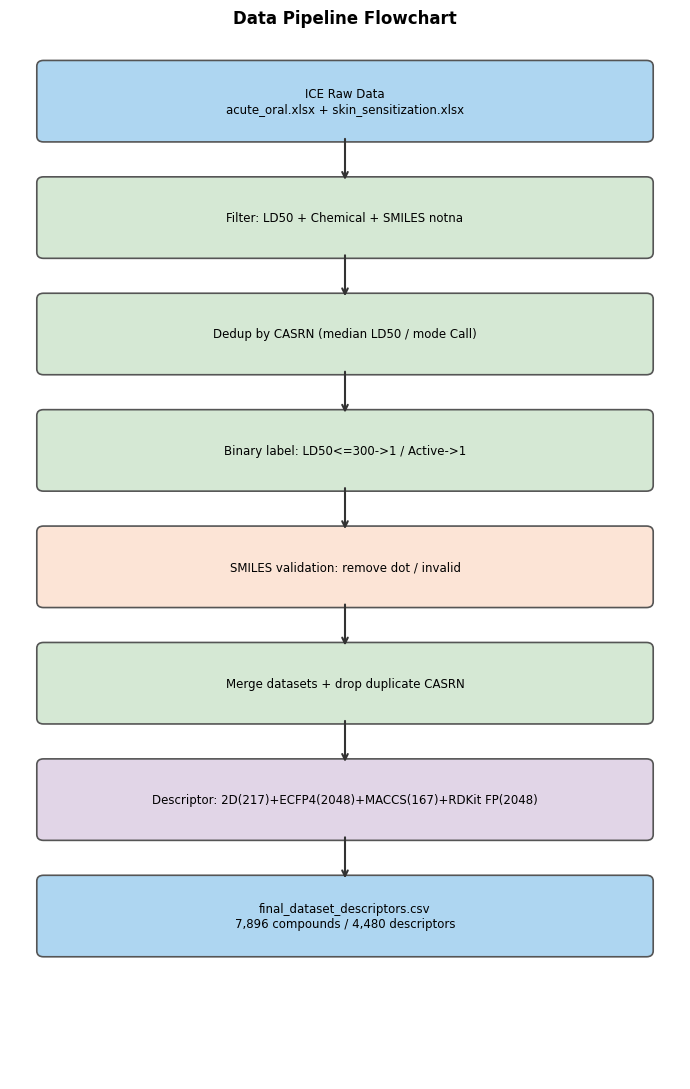

In [2]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(7, 11))
ax.set_xlim(0, 10)
ax.set_ylim(0, 18)
ax.axis('off')

boxes = [
    ('ICE Raw Data\nacute_oral.xlsx + skin_sensitization.xlsx', 16.8, '#AED6F1'),
    ('Filter: LD50 + Chemical + SMILES notna',                  14.8, '#D5E8D4'),
    ('Dedup by CASRN (median LD50 / mode Call)',                12.8, '#D5E8D4'),
    ('Binary label: LD50<=300->1 / Active->1',                  10.8, '#D5E8D4'),
    ('SMILES validation: remove dot / invalid',                   8.8, '#FCE4D6'),
    ('Merge datasets + drop duplicate CASRN',                    6.8, '#D5E8D4'),
    ('Descriptor: 2D(217)+ECFP4(2048)+MACCS(167)+RDKit FP(2048)', 4.8, '#E1D5E7'),
    ('final_dataset_descriptors.csv\n7,896 compounds / 4,480 descriptors', 2.8, '#AED6F1'),
]

for text, y, color in boxes:
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.5, y-0.6), 9, 1.2,
        boxstyle='round,pad=0.1',
        facecolor=color, edgecolor='#555', linewidth=1.2
    ))
    ax.text(5, y, text, ha='center', va='center', fontsize=8.5)

for y_start, y_end in zip([16.2,14.2,12.2,10.2,8.2,6.2,4.2],
                           [15.4,13.4,11.4,9.4,7.4,5.4,3.4]):
    ax.annotate('', xy=(5, y_end), xytext=(5, y_start),
                arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))

ax.set_title('Data Pipeline Flowchart', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [3]:
# LD50 + 단일화합물만 필터링 후 화합물별 중앙값 계산
df = pd.read_excel('acute_oral.xlsx', sheet_name='Data')
df = df[(df['Endpoint']=='LD50') & (df['Mixture']=='Chemical') & df['SMILES'].notna()]
df = df.groupby('CASRN').agg(
    LD50_median=('Response', 'median'),
    SMILES=('SMILES', 'first'),
    Chemical_Name=('Chemical_Name', 'first')
).reset_index()

print('화합물 수:', len(df))

화합물 수: 8794


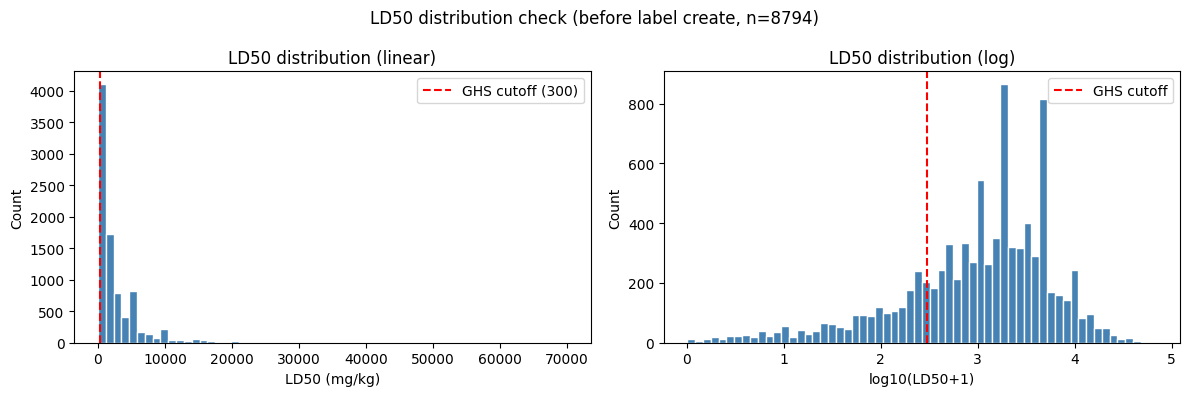

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['LD50_median'], bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(300, color='red', linestyle='--', label='GHS cutoff (300)')
axes[0].set(title='LD50 distribution (linear)', xlabel='LD50 (mg/kg)', ylabel='Count')
axes[0].legend()

axes[1].hist(np.log10(df['LD50_median']+1), bins=60, color='steelblue', edgecolor='white')
axes[1].axvline(np.log10(300), color='red', linestyle='--', label='GHS cutoff')
axes[1].set(title='LD50 distribution (log)', xlabel='log10(LD50+1)', ylabel='Count')
axes[1].legend()

plt.suptitle(f'LD50 distribution check (before label create, n={len(df)})')
plt.tight_layout()
plt.show()

### LD50 분포 확인 결과
- 분포가 오른쪽으로 치우쳐 있어 (right-skewed) → log 변환 시 더 고르게 분포됨
- GHS cutoff(300 mg/kg) 기준으로 왼쪽(Toxic)이 오른쪽(Non-toxic)보다 훨씬 적음
- 커트라인 주변에 화합물이 밀집되지 않아 → GHS 기준 300 mg/kg 적용 적절

In [5]:
# GHS 기준: LD50 <= 300 mg/kg → Toxic(1), 초과 → Non-toxic(0)
df['label'] = (df['LD50_median'] <= 300).astype(int)
print(f'label 분포: {df["label"].value_counts().to_dict()}')

label 분포: {0: 6849, 1: 1945}


In [6]:
# dot 포함(염/혼합물) + invalid SMILES 제거
def check_smiles(smi):
    if '.' in str(smi): return 'dot'
    if Chem.MolFromSmiles(str(smi)) is None: return 'invalid'
    return 'valid'

df['status'] = df['SMILES'].apply(check_smiles)
print(df['status'].value_counts())

df_original = df.copy()  # status 컬럼 생성 후 원본 보존

df = df[df['status'] == 'valid'].reset_index(drop=True)
print(f'최종 유효 화합물: {len(df)}')

status
valid      7309
dot        1481
invalid       4
Name: count, dtype: int64
최종 유효 화합물: 7309


In [7]:
# PubChem API로 dot/invalid SMILES 보충 시도
# → 조회 결과 단일 SMILES 대체 불가 (염 형태는 PubChem에서도 동일하게 dot 포함 SMILES 반환)
# → 아래 코드는 참고용으로 남겨두며, 실제 실행은 생략

if False:
    def fetch_smiles_pubchem(casrn):
        url = f'https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{casrn}/property/CanonicalSMILES/JSON'
        try:
            r = requests.get(url, timeout=5)
            if r.status_code == 200:
                return r.json()['PropertyTable']['Properties'][0]['CanonicalSMILES']
        except:
            pass
        return None

    def is_valid_single(smi):
        if smi is None or '.' in str(smi): return False
        return Chem.MolFromSmiles(str(smi)) is not None

    target = df[df['status'] != 'valid']
    for i, (idx, row) in enumerate(target.iterrows()):
        new_smi = fetch_smiles_pubchem(row['CASRN'])
        if is_valid_single(new_smi):
            df.at[idx, 'SMILES'] = new_smi
            df.at[idx, 'status'] = 'valid'
        if (i+1) % 100 == 0:
            print(f'  {i+1}/{len(target)} 완료')
        time.sleep(0.2)

In [8]:
from rdkit.Chem.SaltRemover import SaltRemover

# dot 포함 분자에서 Salt 제거 후 유효 분자 복구 시도
remover = SaltRemover()
dot_df = df_original[df_original['status'] == 'dot'].copy()
recovered = []

for _, row in dot_df.iterrows():
    mol = Chem.MolFromSmiles(row['SMILES'])
    if mol is None:
        continue
    try:
        mol_clean = remover.StripMol(mol)
        smi_clean = Chem.MolToSmiles(mol_clean)
        if smi_clean and '.' not in smi_clean:
            row_copy = row.copy()
            row_copy['SMILES'] = smi_clean
            row_copy['status'] = 'valid'
            recovered.append(row_copy)
    except:
        continue

df_recovered = pd.DataFrame(recovered)
print(f'Salt 제거로 복구된 분자: {len(df_recovered)}개')

df = pd.concat([df[df['status']=='valid'], df_recovered]).reset_index(drop=True)
print(f'최종 유효 화합물: {len(df)}개')

Salt 제거로 복구된 분자: 1350개
최종 유효 화합물: 8659개


### Salt 제거 시도 결과
- RDKit SaltRemover로 dot 포함 1,481개 분자 복구 시도
- 복구된 분자: 1,350개 (전체의 약 15% 추가 확보)
- 원인: 카운터 이온(Counter ion) 제거 후 유효한 유기 분자 본체 추출 성공
- 결론: 7,309개 → 8,659개로 증가

In [9]:
# Call endpoint + 단일화합물만 필터링 후 화합물별 최빈값 레이블
df_skin = pd.read_excel('skin_sensitization.xlsx', sheet_name='Data_invivo')
df_skin = df_skin[
    (df_skin['Endpoint'] == 'Call') &
    (df_skin['Mixture'] == 'Chemical') &
    df_skin['SMILES'].notna()
].copy()

df_skin = df_skin.groupby('CASRN').agg(
    Response=('Response', lambda x: x.mode()[0]),
    SMILES=('SMILES', 'first'),
    Chemical_Name=('Chemical_Name', 'first')
).reset_index()

df_skin['label'] = (df_skin['Response'] == 'Active').astype(int)
df_skin = df_skin.drop(columns='Response')
df_skin = df_skin[df_skin['SMILES'].apply(check_smiles) == 'valid'].reset_index(drop=True)

print('Skin Sensitization 화합물 수:', len(df_skin))
print('label 분포:', df_skin['label'].value_counts().to_dict())

Skin Sensitization 화합물 수: 1117
label 분포: {0: 927, 1: 190}


## 데이터 통합 — Acute Oral Toxicity + Skin Sensitization

두 데이터셋 모두 NTP ICE에서 제공하는 독성 데이터이며,
"독성 있음(1) / 없음(0)" 이진 분류 문제로 레이블 체계가 동일하다.

- **Acute Oral Toxicity**: 경구 투여 시 전신 독성 (LD50 ≤ 300 mg/kg → Toxic)
- **Skin Sensitization**: 피부 접촉 시 감작 반응 (Active → Sensitizer)

두 데이터셋을 통합해 더 다양한 화합물 구조를 학습 데이터로 확보하고,
CASRN 기준으로 중복 화합물은 제거한다.

In [10]:
df['source']      = 'acute_oral'
df_skin['source'] = 'skin_sensitization'

df_combined = pd.concat(
    [df[['CASRN','Chemical_Name','SMILES','label','source']],
     df_skin[['CASRN','Chemical_Name','SMILES','label','source']]],
    ignore_index=True
)
df_combined = df_combined.drop_duplicates(subset='CASRN').reset_index(drop=True)

print('acute_oral:', len(df))
print('skin_sensitization:', len(df_skin))
print('합친 후 전체 화합물:', len(df_combined))
print('label 분포:', df_combined['label'].value_counts().to_dict())
print('데이터 출처:', df_combined['source'].value_counts().to_dict())

acute_oral: 8659
skin_sensitization: 1117
합친 후 전체 화합물: 9246
label 분포: {0: 7211, 1: 2035}
데이터 출처: {'acute_oral': 8659, 'skin_sensitization': 587}


In [11]:
# 두 데이터셋에 겹치는 CASRN 중 label이 다른 경우 확인
overlap = pd.merge(
    df[['CASRN','label']].rename(columns={'label':'label_oral'}),
    df_skin[['CASRN','label']].rename(columns={'label':'label_skin'}),
    on='CASRN'
)
conflict = overlap[overlap['label_oral'] != overlap['label_skin']]
print(f'겹치는 CASRN: {len(overlap)}개')
print(f'label 충돌: {len(conflict)}개')
print('→ 충돌 화합물은 acute_oral 기준 유지 (concat 순서상 first)')

겹치는 CASRN: 530개
label 충돌: 84개
→ 충돌 화합물은 acute_oral 기준 유지 (concat 순서상 first)


### CASRN 중복 충돌 처리 결과
- 두 데이터셋에 겹치는 CASRN: 530개
- label 충돌 (두 데이터셋 간 label이 다른 경우): 84개
- 원인: 경구 독성(Acute Oral)과 피부 감작(Skin Sensitization)은 독성 메커니즘이 달라 동일 화합물이라도 label이 다를 수 있음
- 처리: concat 순서상 acute_oral이 먼저이므로 drop_duplicates(keep='first')로 acute_oral label 유지
- 향후 개선: Multi-task Learning으로 label_oral / label_skin 분리 설계 권장

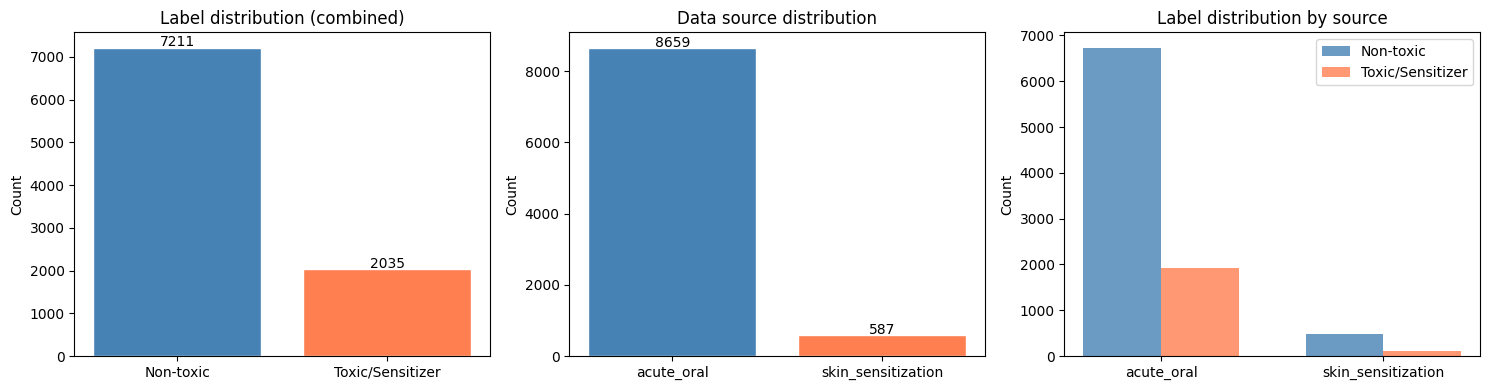

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

vc = df_combined['label'].value_counts()
axes[0].bar(['Non-toxic','Toxic/Sensitizer'], vc.values,
            color=['steelblue','coral'], edgecolor='white')
for i, v in enumerate(vc.values): axes[0].text(i, v+30, str(v), ha='center')
axes[0].set(title='Label distribution (combined)', ylabel='Count')

sc = df_combined['source'].value_counts()
axes[1].bar(sc.index, sc.values, color=['steelblue','coral'], edgecolor='white')
for i, v in enumerate(sc.values): axes[1].text(i, v+30, str(v), ha='center')
axes[1].set(title='Data source distribution', ylabel='Count')

sources = df_combined['source'].unique()
x = np.arange(len(sources))
for offset, (lb, col, nm) in enumerate([(0,'steelblue','Non-toxic'),(1,'coral','Toxic/Sensitizer')]):
    vals = [df_combined[df_combined['source']==s]['label'].eq(lb).sum() for s in sources]
    axes[2].bar(x + offset*0.35, vals, 0.35, color=col, alpha=0.8, label=nm)
axes[2].set_xticks(x + 0.175)
axes[2].set_xticklabels(sources)
axes[2].set(title='Label distribution by source', ylabel='Count')
axes[2].legend()

plt.tight_layout()
plt.show()

In [13]:
n0 = (df_combined['label']==0).sum()
n1 = (df_combined['label']==1).sum()
print(f'Non-toxic : Toxic = {n0} : {n1} = {n0/n1:.1f} : 1')
print(f'Toxic 비율: {n1/(n0+n1):.1%}')
print('→ 클래스 불균형 존재 → Balanced Accuracy, ROC-AUC 사용 권장')

Non-toxic : Toxic = 7211 : 2035 = 3.5 : 1
Toxic 비율: 22.0%
→ 클래스 불균형 존재 → Balanced Accuracy, ROC-AUC 사용 권장


In [14]:
# 4종 descriptor: 2D descriptor + ECFP4 + MACCS Keys + RDKit Fingerprint
desc_fns = Descriptors.descList
gen = AllChem.GetMorganGenerator(radius=2, fpSize=2048)

rows, valid_idx, skipped = [], [], 0

for i, smi in enumerate(df_combined['SMILES']):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        continue
    try:
        d2d   = [fn(mol) for _, fn in desc_fns]
        ecfp4 = list(gen.GetFingerprint(mol))
        maccs = list(rdMolDescriptors.GetMACCSKeysFingerprint(mol))
        rdkfp = list(Chem.RDKFingerprint(mol))
        rows.append(d2d + ecfp4 + maccs + rdkfp)
        valid_idx.append(i)
    except Exception:
        skipped += 1
        continue

print(f'에러로 스킵된 분자: {skipped}개')
df_combined = df_combined.iloc[valid_idx].reset_index(drop=True)

cols = ([n for n,_ in desc_fns]
      + [f'ECFP4_{i}'  for i in range(2048)]
      + [f'MACCS_{i}'  for i in range(167)]
      + [f'RDKFP_{i}'  for i in range(2048)])

df_desc = pd.DataFrame(rows, columns=cols)
print(f'2D descriptor : 217개')
print(f'ECFP4         : 2048개')
print(f'MACCS Keys    : 167개')
print(f'RDKit FP      : 2048개')
print(f'총             : {df_desc.shape[1]}개')
print(f'최종 화합물 수 : {len(df_combined)}개')

에러로 스킵된 분자: 0개
2D descriptor : 217개
ECFP4         : 2048개
MACCS Keys    : 167개
RDKit FP      : 2048개
총             : 4480개
최종 화합물 수 : 9246개


In [15]:
# inf → nan 변환 후 중앙값으로 채우기
df_desc = df_desc.replace([np.inf, -np.inf], np.nan)
df_desc = df_desc.fillna(df_desc.median())
print('결측치/Inf 처리 완료')
print('남은 NaN:', df_desc.isna().sum().sum())

결측치/Inf 처리 완료
남은 NaN: 0


In [16]:
# 중간 저장 (Variance Thresholding 후 덮어쓰기 전)
df_final = pd.concat(
    [df_combined[['CASRN','Chemical_Name','SMILES','label','source']], df_desc],
    axis=1
)
df_final.to_csv('final_dataset_descriptors.csv', index=False)
print('중간 저장 완료:', df_final.shape)

중간 저장 완료: (9246, 4485)


In [17]:
from sklearn.feature_selection import VarianceThreshold

# Fingerprint 열만 대상으로 Variance Thresholding
# (2D descriptor는 이미 의미있는 값들이라 제외, fingerprint 0/1 이진값 열만 필터링)
fp_cols  = [c for c in df_desc.columns
            if c.startswith('ECFP4') or c.startswith('MACCS') or c.startswith('RDKFP')]
desc_cols = [c for c in df_desc.columns
             if not (c.startswith('ECFP4') or c.startswith('MACCS') or c.startswith('RDKFP'))]

# threshold=0.01: 거의 모든 분자에서 0이거나 1인 열 제거
vt = VarianceThreshold(threshold=0.01)
vt.fit(df_desc[fp_cols])

fp_cols_keep = [fp_cols[i] for i in range(len(fp_cols)) if vt.get_support()[i]]
print(f'Fingerprint 열 전체: {len(fp_cols)}개')
print(f'제거된 열 (low variance): {len(fp_cols) - len(fp_cols_keep)}개')
print(f'남은 Fingerprint 열: {len(fp_cols_keep)}개')

# 2D descriptor + 살아남은 fingerprint 합치기
df_desc_filtered = pd.concat([df_desc[desc_cols], df_desc[fp_cols_keep]], axis=1)
print(f'\n필터링 전: {df_desc.shape[1]}개 → 필터링 후: {df_desc_filtered.shape[1]}개')

# 저장 덮어쓰기
df_final_filtered = pd.concat(
    [df_combined[['CASRN','Chemical_Name','SMILES','label','source']], df_desc_filtered],
    axis=1
)
df_final_filtered.to_csv('final_dataset_descriptors.csv', index=False)
print('저장 완료:', df_final_filtered.shape)

Fingerprint 열 전체: 4263개
제거된 열 (low variance): 1537개
남은 Fingerprint 열: 2726개

필터링 전: 4480개 → 필터링 후: 2943개
저장 완료: (9246, 2948)


In [18]:
from sklearn.preprocessing import StandardScaler

# 2D descriptor만 표준화 (fingerprint 0/1 이진값은 스케일링 불필요)
desc_only_cols = [c for c in df_desc_filtered.columns
                  if not (c.startswith('ECFP4') or
                          c.startswith('MACCS') or
                          c.startswith('RDKFP'))]
fp_only_cols = [c for c in df_desc_filtered.columns
                if c.startswith('ECFP4') or
                   c.startswith('MACCS') or
                   c.startswith('RDKFP')]

scaler = StandardScaler()
desc_scaled = scaler.fit_transform(df_desc_filtered[desc_only_cols])
df_desc_scaled = pd.DataFrame(desc_scaled, columns=desc_only_cols)

# 표준화된 2D descriptor + fingerprint 합치기
df_desc_final = pd.concat([df_desc_scaled,
                            df_desc_filtered[fp_only_cols].reset_index(drop=True)],
                           axis=1)

# 최종 저장
df_final_scaled = pd.concat(
    [df_combined[['CASRN','Chemical_Name','SMILES','label','source']].reset_index(drop=True),
     df_desc_final],
    axis=1
)
df_final_scaled.to_csv('final_dataset_descriptors.csv', index=False)
print('최종 저장 완료 (2D descriptor 표준화 포함):', df_final_scaled.shape)

최종 저장 완료 (2D descriptor 표준화 포함): (9246, 2948)


## 데이터 파이프라인 요약

| 단계 | 화합물 수 |
|---|---:|
| Raw Acute Oral (LD50) | 8,794 |
| Valid SMILES (dot/invalid 제거) | 7,309 |
| SaltRemover 복구 (+1,350) | 8,659 |
| Skin Sensitization (Call endpoint) | 1,117 |
| 병합 후 (CASRN 중복 제거) | 실행 결과 참조 |
| Variance Thresholding 후 descriptor 수 | 실행 결과 참조 |

- 클래스 불균형 존재 → Balanced Accuracy, ROC-AUC 사용 권장
- CASRN 중복 충돌: 84개 → acute_oral 기준 유지
- 최종 저장: final_dataset_descriptors.csv (2D descriptor 표준화 포함)

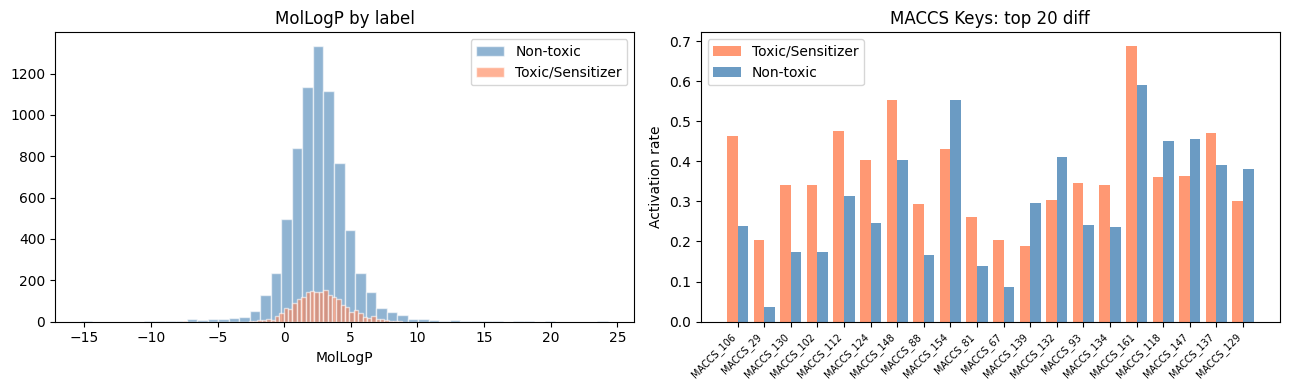

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for lb, col, nm in [(0,'steelblue','Non-toxic'),(1,'coral','Toxic/Sensitizer')]:
    axes[0].hist(df_desc.loc[df_combined['label']==lb,'MolLogP'],
                 bins=50, alpha=0.6, color=col, label=nm, edgecolor='white')
axes[0].set(title='MolLogP by label', xlabel='MolLogP')
axes[0].legend()

maccs_cols = [c for c in df_desc.columns if c.startswith('MACCS')]
diff = (df_desc.loc[df_combined['label']==1, maccs_cols].mean()
      - df_desc.loc[df_combined['label']==0, maccs_cols].mean()).abs()
top20 = diff.nlargest(20)
x = np.arange(20)
axes[1].bar(x-0.2, df_desc.loc[df_combined['label']==1, top20.index].mean(),
            0.4, color='coral', alpha=0.8, label='Toxic/Sensitizer')
axes[1].bar(x+0.2, df_desc.loc[df_combined['label']==0, top20.index].mean(),
            0.4, color='steelblue', alpha=0.8, label='Non-toxic')
axes[1].set_xticks(x)
axes[1].set_xticklabels(top20.index, rotation=45, ha='right', fontsize=7)
axes[1].set(title='MACCS Keys: top 20 diff', ylabel='Activation rate')
axes[1].legend()

plt.tight_layout()
plt.show()

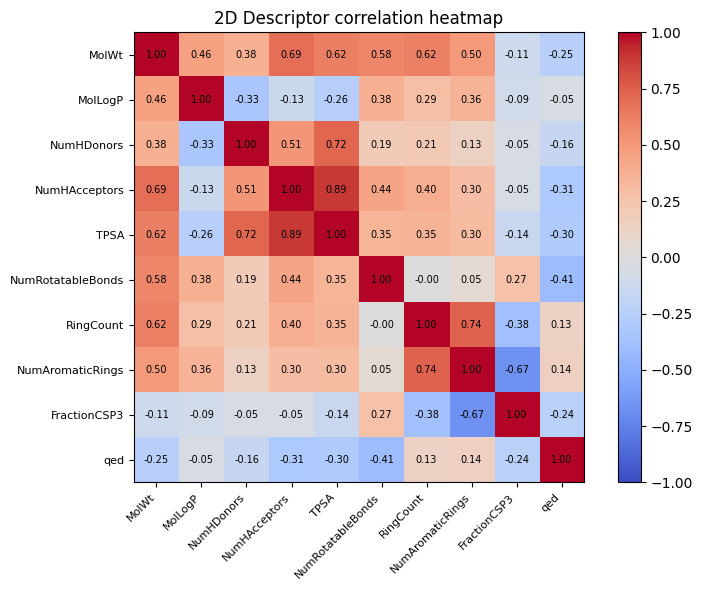

In [20]:
top_desc = ['MolWt','MolLogP','NumHDonors','NumHAcceptors',
            'TPSA','NumRotatableBonds','RingCount','NumAromaticRings','FractionCSP3','qed']
corr = df_desc[top_desc].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(top_desc, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(top_desc, fontsize=8)
for i in range(10):
    for j in range(10):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=7)
ax.set_title('2D Descriptor correlation heatmap')
plt.tight_layout()
plt.show()

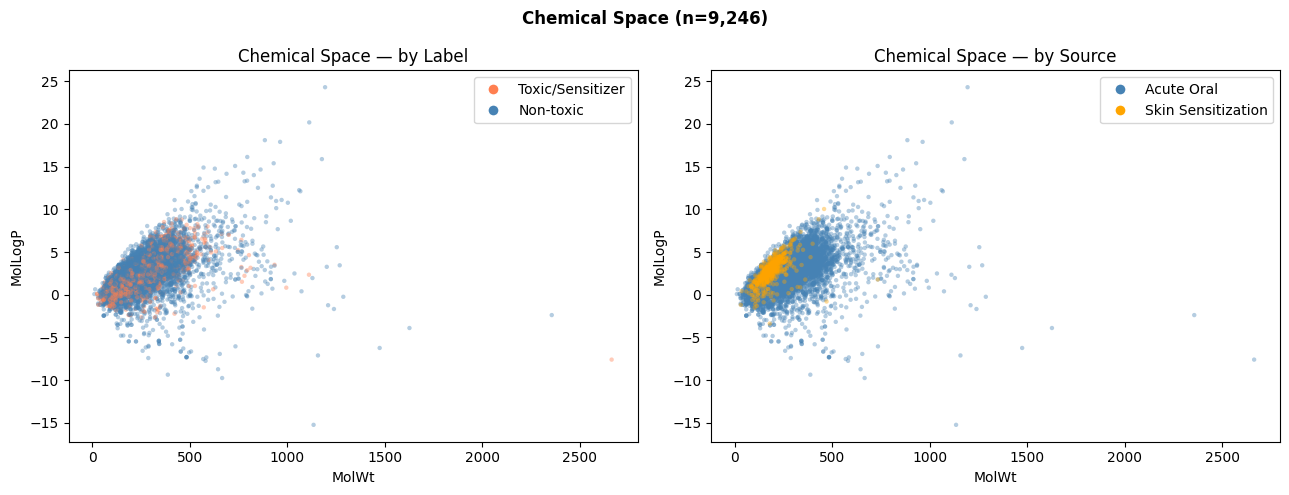

In [21]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df_desc['MolWt'], df_desc['MolLogP'],
                c=df_combined['label'].map({0:'steelblue', 1:'coral'}),
                alpha=0.4, s=10, linewidths=0)
axes[0].set(title='Chemical Space — by Label', xlabel='MolWt', ylabel='MolLogP')
axes[0].legend(handles=[
    Line2D([0],[0], marker='o', color='w', markerfacecolor='coral',     markersize=8, label='Toxic/Sensitizer'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', markersize=8, label='Non-toxic'),
])

axes[1].scatter(df_desc['MolWt'], df_desc['MolLogP'],
                c=df_combined['source'].map({'acute_oral':'steelblue','skin_sensitization':'orange'}),
                alpha=0.4, s=10, linewidths=0)
axes[1].set(title='Chemical Space — by Source', xlabel='MolWt', ylabel='MolLogP')
axes[1].legend(handles=[
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', markersize=8, label='Acute Oral'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='orange',    markersize=8, label='Skin Sensitization'),
])

plt.suptitle(f'Chemical Space (n={len(df_combined):,})', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

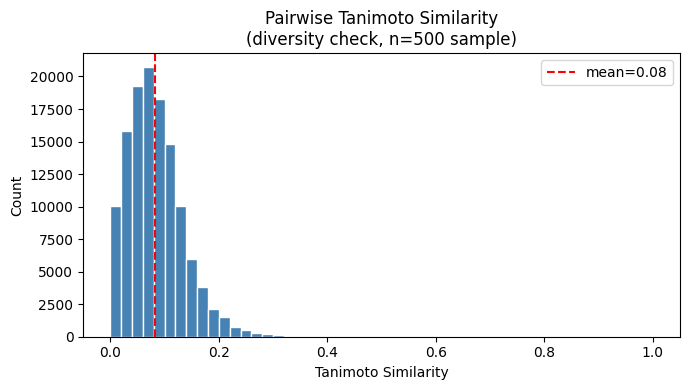

평균 유사도: 0.083
→ 낮을수록 화합물 구조가 다양함


In [22]:
from rdkit.Chem import DataStructs

# 샘플 500개로 pairwise Tanimoto 계산
sample = df_combined.sample(500)
gen_morgan = AllChem.GetMorganGenerator(radius=2, fpSize=2048)
fps = [gen_morgan.GetFingerprint(Chem.MolFromSmiles(s)) for s in sample['SMILES']]

sims = []
for i in range(len(fps)):
    for j in range(i+1, len(fps)):
        sims.append(DataStructs.TanimotoSimilarity(fps[i], fps[j]))

plt.figure(figsize=(7, 4))
plt.hist(sims, bins=50, color='steelblue', edgecolor='white')
plt.axvline(np.mean(sims), color='red', linestyle='--',
            label=f'mean={np.mean(sims):.2f}')
plt.xlabel('Tanimoto Similarity')
plt.ylabel('Count')
plt.title('Pairwise Tanimoto Similarity\n(diversity check, n=500 sample)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'평균 유사도: {np.mean(sims):.3f}')
print('→ 낮을수록 화합물 구조가 다양함')

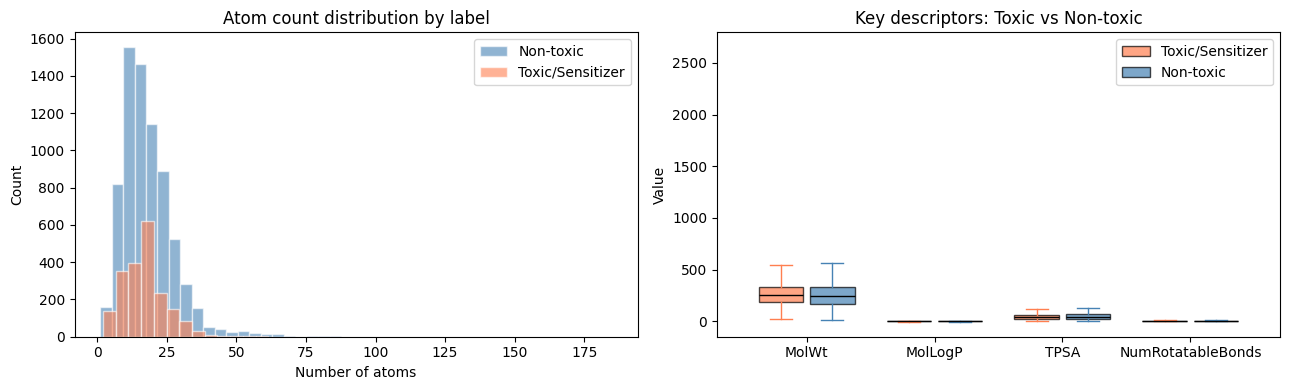

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

atom_counts = df_combined['SMILES'].apply(lambda s: Chem.MolFromSmiles(s).GetNumAtoms())
for lb, col, nm in [(0,'steelblue','Non-toxic'),(1,'coral','Toxic/Sensitizer')]:
    axes[0].hist(atom_counts[df_combined['label']==lb], bins=40,
                 alpha=0.6, color=col, label=nm, edgecolor='white')
axes[0].set(title='Atom count distribution by label', xlabel='Number of atoms', ylabel='Count')
axes[0].legend()

desc_box = ['MolWt','MolLogP','TPSA','NumRotatableBonds']
data_toxic    = [df_desc.loc[df_combined['label']==1, d].values for d in desc_box]
data_nontoxic = [df_desc.loc[df_combined['label']==0, d].values for d in desc_box]
x = np.arange(len(desc_box))

bp1 = axes[1].boxplot(data_toxic,    positions=x-0.2, widths=0.35, patch_artist=True,
                      boxprops=dict(facecolor='coral',     alpha=0.7),
                      medianprops=dict(color='black'),
                      whiskerprops=dict(color='coral'),
                      capprops=dict(color='coral'),
                      flierprops=dict(marker=''))
bp2 = axes[1].boxplot(data_nontoxic, positions=x+0.2, widths=0.35, patch_artist=True,
                      boxprops=dict(facecolor='steelblue', alpha=0.7),
                      medianprops=dict(color='black'),
                      whiskerprops=dict(color='steelblue'),
                      capprops=dict(color='steelblue'),
                      flierprops=dict(marker=''))
axes[1].set_xticks(x)
axes[1].set_xticklabels(desc_box)
axes[1].set(title='Key descriptors: Toxic vs Non-toxic', ylabel='Value')
axes[1].legend([bp1['boxes'][0], bp2['boxes'][0]], ['Toxic/Sensitizer','Non-toxic'])

plt.tight_layout()
plt.show()

In [24]:
ro5 = (
    (df_desc['MolWt'] <= 500) &
    (df_desc['MolLogP'] <= 5) &
    (df_desc['NumHDonors'] <= 5) &
    (df_desc['NumHAcceptors'] <= 10)
)
print(f'Lipinski Rule of 5 통과: {ro5.sum()}개 ({ro5.mean():.1%})')
print(f'통과 못 함: {(~ro5).sum()}개')
print()
for lb, nm in [(0,'Non-toxic'),(1,'Toxic/Sensitizer')]:
    mask = df_combined['label'] == lb
    rate = ro5[mask].mean()
    print(f'{nm}: Ro5 통과율 {rate:.1%}')

Lipinski Rule of 5 통과: 8014개 (86.7%)
통과 못 함: 1232개

Non-toxic: Ro5 통과율 86.5%
Toxic/Sensitizer: Ro5 통과율 87.1%
